In [227]:
# Load in pos files and plot a series of events on one graph for prez

#Imports
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import CRS, Transformer
from concurrent.futures import ThreadPoolExecutor
from typing import Tuple
import numpy as np
from datetime import datetime
import os
from Datastream import Datastream
from collections import defaultdict

# Path
sta_path = "/Users/sambrown04/Documents/SURF/PPP"
stas = ["la01", "la02", "la03", "la04", "la05", "la06", "la07", "la08", "la09",
        "la10", "la11", "la12", "la13", "la14", "la15", "la16", "la17", "la18",
        "ws04", "ws05",
        "gz01", "gz02", "gz03", "gz04", "gz05", "gz06", "gz07", "gz08", "gz09",
        "gz10", "gz11", "gz12", "gz13", "gz14", "gz15", "gz16", "gz17", "gz18",
        "gz19", "gz20",
        "mg01", "mg02", "mg03", "mg04", "mg05", "mg06", "mg07",
        "slw1"
        ]
year_arr = [["2008"],["2009"],["2010"],["2011"],["2012"],['2013'],['2014'],['2015'],["2016"],["2017"],["2018"],["2019"]]
   

In [229]:
def load_station(sta: str, years: list, directory: str) -> Datastream:
    """
    Load a station's worth of data for the years specified.
 
    Parameters
    ----------
    sta: str
        Station name
    years : list
        List of year folders to include in this data stream.

    returns
    -------
    Datastream
    Datastream object containing the data in the position file
    """
    cat = Datastream(os.path.join(directory, sta), sta, years)
    return cat

# Load stations in parallel
with ThreadPoolExecutor() as executor:
    results = executor.map(load_station, stas, [year_arr] * len(stas), [sta_path] * len(stas))

cats = [cat for cat in results if cat is not None]

In [235]:
# Want to make a list of dataframes for the year 2011 where each dataframe corresponds to a station that was up during that time


dfs_by_year = defaultdict(list)
years = range(2010, 2013)

for cat in cats:
    df = cat.data

    if "time" not in df.columns or df.empty:
        continue

    print(cat.name, df["time"].min(), df["time"].max())

    for yr in years:
        start = pd.to_datetime(f"{yr}-01-01")
        end = pd.to_datetime(f"{yr}-12-31 23:59:59")

        df_yr = df[(df["time"] >= start) & (df["time"] <= end)].copy()
        if not df_yr.empty:
            df_yr["station"] = cat.name
            dfs_by_year[yr].append(df_yr)

print("2011:", len(dfs_by_year[2011]), "stations")
# ERROR needs fixing

2011: 0 stations


0         2010-01-19 00:38:15
1         2010-01-19 00:38:30
2         2010-01-19 00:38:45
3         2010-01-19 00:39:00
4         2010-01-19 00:39:15
                  ...        
3102069   2011-12-31 23:58:45
3102070   2011-12-31 23:59:00
3102071   2011-12-31 23:59:15
3102072   2011-12-31 23:59:30
3102073   2011-12-31 23:59:45
Name: time, Length: 3102074, dtype: datetime64[ns]
0         2010-01-19 01:44:15
1         2010-01-19 01:44:30
2         2010-01-19 01:44:45
3         2010-01-19 01:45:00
4         2010-01-19 01:45:15
                  ...        
3062182   2011-12-31 23:58:45
3062183   2011-12-31 23:59:00
3062184   2011-12-31 23:59:15
3062185   2011-12-31 23:59:30
3062186   2011-12-31 23:59:45
Name: time, Length: 3062187, dtype: datetime64[ns]


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


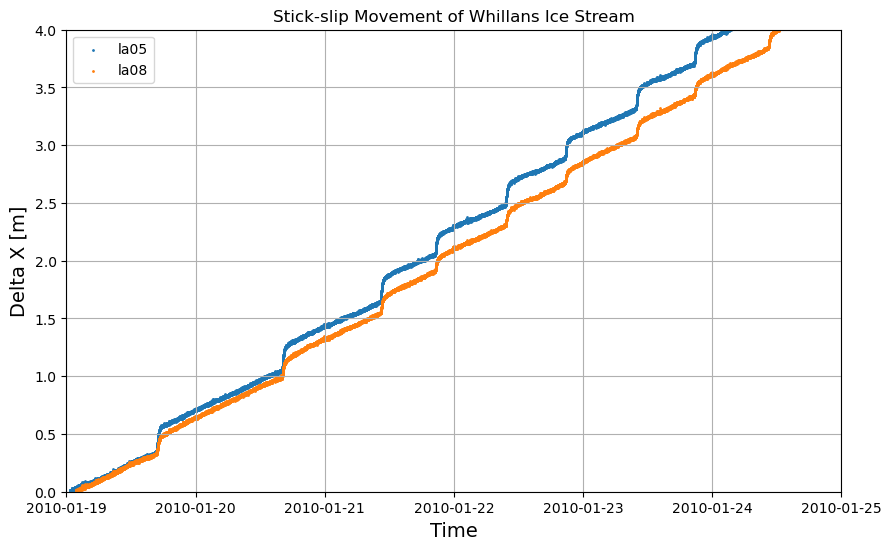

In [188]:
# Plot
start = pd.to_datetime("2010-01-19")
end   = pd.to_datetime("2010-01-25 ")
fig, ax = plt.subplots(figsize=(10,6))
for cat in cats:
    times = pd.to_datetime(cat.data["time"])
    print(times)
    ax.scatter(times,cat.data['x'] - cat.data['x'].iloc[0], label=cat.name, s =1)
ax.set_xlim(start,end)  
ax.set_ylim(0,4)
ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Delta X [m]", fontsize=14)
ax.legend()
ax.set_title("Stick-slip Movement of Whillans Ice Stream")
plt.grid()
plt.show()